# S&P 500 Sector Analysis (2010–2020)

End-to-end risk-return profiling of 11 GICS sectors using sector ETFs (XLB, XLC, XLE, XLF, XLI, XLK, XLP, XLRE, XLU, XLV, XLY).

**Metrics:** Annualized Return · Annualized Volatility · Sharpe Ratio · Max Drawdown  
**Data source:** yfinance (adjusted close prices)  
**Period:** January 2010 – December 2020

In [1]:
import sys
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import pandas as pd
from src.data_loader import download_prices, compute_returns, save_to_db, load_returns
from src.metrics import sector_summary
from src.visualizations import plot_sector_returns, plot_risk_return_scatter, plot_correlation_heatmap

## 1. Load Data

Load daily returns from the SQLite database. If the database does not exist yet, the cell downloads data automatically (~30 seconds).

In [2]:
try:
    returns = load_returns()
    print(f'Loaded {len(returns):,} rows from database.')
except Exception:
    print('Database not found — downloading data (~30 seconds)...')
    prices = download_prices()
    returns = compute_returns(prices)
    save_to_db(prices, returns)
    print(f'Done. Loaded {len(returns):,} rows.')

Loaded 26,857 rows from database.


In [3]:
print(f'Shape: {returns.shape}')
print('Date range:', returns['date'].min(), 'to', returns['date'].max())
print('Sectors:', sorted(returns['sector'].unique()))
returns.head(8)

Shape: (26857, 4)
Date range: 2010-01-05 00:00:00 to 2020-12-30 00:00:00
Sectors: ['Communication Services', 'Consumer Discretionary', 'Consumer Staples', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Materials', 'Real Estate', 'Technology', 'Utilities']


,date,ticker,sector,daily_return
0,2010-01-05,XLB,Materials,0.003233
1,2010-01-06,XLB,Materials,0.016994
2,2010-01-07,XLB,Materials,-0.007779
3,2010-01-08,XLB,Materials,0.013937
4,2010-01-11,XLB,Materials,-0.005441
5,2010-01-12,XLB,Materials,-0.019004
6,2010-01-13,XLB,Materials,0.011740
7,2010-01-14,XLB,Materials,-0.012184


## 2. Risk-Return Metrics

Compute annualized return, volatility, Sharpe ratio (risk-free rate = 2%), and max drawdown for each sector over the full 10-year period.

In [4]:
summary = sector_summary(returns)

(
    summary.set_index('sector')
    .style
    .format({
        'annualized_return': '{:.2%}',
        'annualized_volatility': '{:.2%}',
        'sharpe_ratio': '{:.3f}',
        'max_drawdown': '{:.2%}',
    })
    .background_gradient(subset=['sharpe_ratio'], cmap='RdYlGn')
    .background_gradient(subset=['max_drawdown'], cmap='RdYlGn_r')
)

,annualized_return,annualized_volatility,max_drawdown,sharpe_ratio
sector,,,,
Consumer Discretionary,18.43%,18.54%,-33.91%,0.886
Technology,19.32%,20.25%,-31.15%,0.855
Health Care,14.72%,16.88%,-28.40%,0.754
Consumer Staples,12.09%,14.02%,-24.51%,0.720
Industrials,14.45%,20.33%,-42.33%,0.612
Communication Services,15.73%,25.45%,-30.15%,0.540
Utilities,11.45%,17.60%,-36.07%,0.537
Financials,12.63%,23.23%,-42.86%,0.458
Materials,11.40%,21.61%,-37.27%,0.435


## 3. Visualizations

### 3.1 Annualized Return by Sector

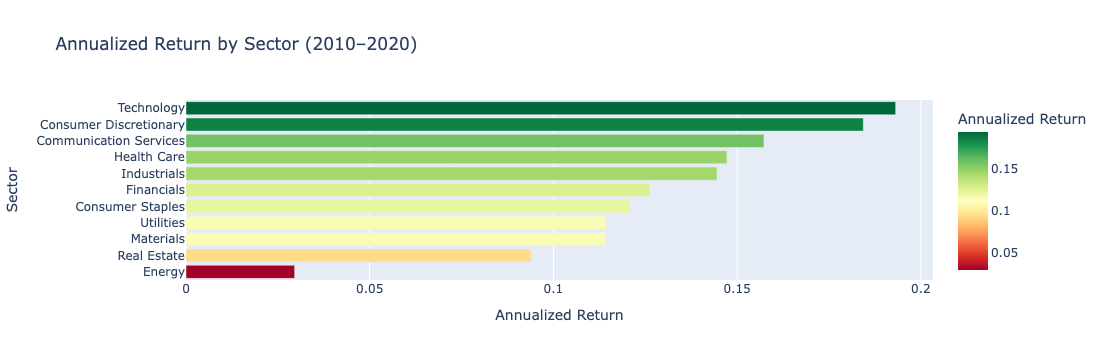

In [5]:
plot_sector_returns(summary).show()

### 3.2 Risk vs. Return

Bubble size represents Sharpe ratio. Upper-left quadrant = high return per unit of risk.

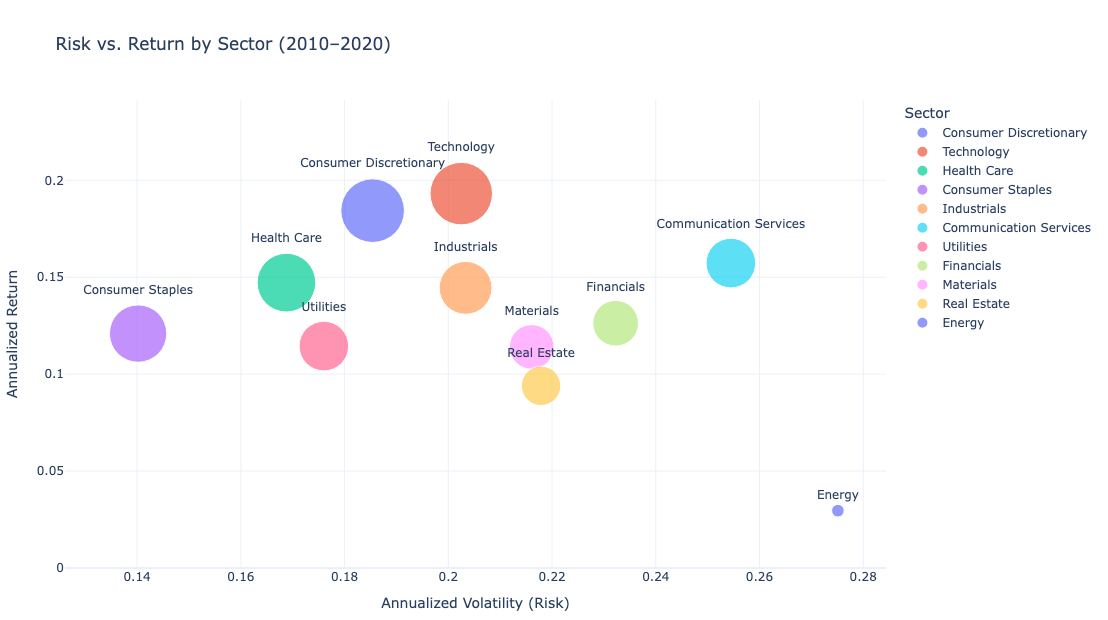

In [6]:
plot_risk_return_scatter(summary).show()

### 3.3 Sector Return Correlation Matrix

Values near 1 indicate sectors that move together, reducing diversification benefit.

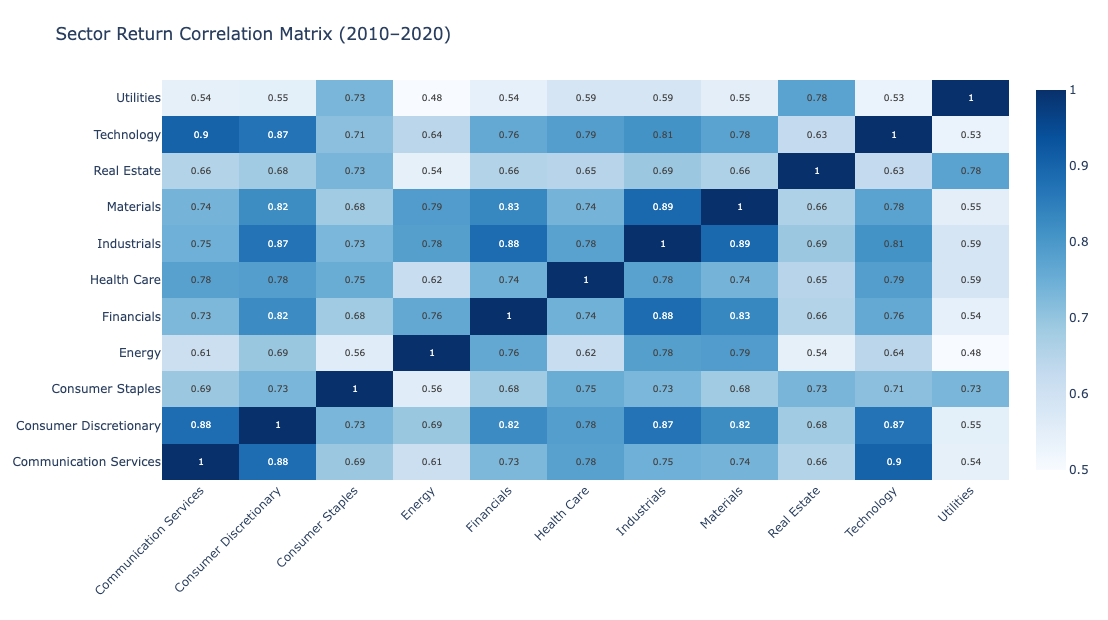

In [7]:
returns_wide = returns.pivot_table(index='date', columns='sector', values='daily_return')
plot_correlation_heatmap(returns_wide).show()

## 4. Key Findings

| Sector | Takeaway |
|--------|----------|
| **Technology (XLK)** | Highest annualized return and Sharpe ratio — dominated the decade |
| **Energy (XLE)** | Worst performer; deep drawdowns driven by oil cycles and the 2020 demand collapse |
| **Health Care (XLV)** | Strong risk-adjusted returns with relatively low drawdown |
| **Utilities / Consumer Staples** | Lowest volatility; classic defensive characteristics |
| **Correlation structure** | Most sectors show moderate-to-high correlation (≥0.6), limiting intra-equity diversification |

**Takeaway:** The 2010–2020 period strongly favored growth sectors. A mean-variance efficient frontier would over-weight Technology and Health Care while minimizing Energy exposure.